<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9240\1490582498.py:8: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_excel("C:\Default-Predict\hmeq.xlsx", sheet_name=0, engine="openpyxl") # Giả định sheet đầu tiên là dữ liệu
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Số dòng: 5960
Số cột: 14

Tên các biến: ['REASON', 'JOB', 'BAD', 'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'gDEBTINC']

Missing values theo từng biến:
          MissingCount  MissingPercent
DEBTINC           1267       21.258389
DEROG              708       11.879195
DELINQ             580        9.731544
MORTDUE            518        8.691275
YOJ                515        8.640940
NINQ               510        8.557047
CLAGE              308        5.167785
JOB                279        4.681208
REASON             252        4.228188
CLNO               222        3.724832
VALUE              112        1.879195
LOAN                 0        0.000000
BAD                  0        0.000000
gDEBTINC             0        0.000000

Tổng số dòng có ít nhất một giá trị thiếu: 2596 (43.56%)


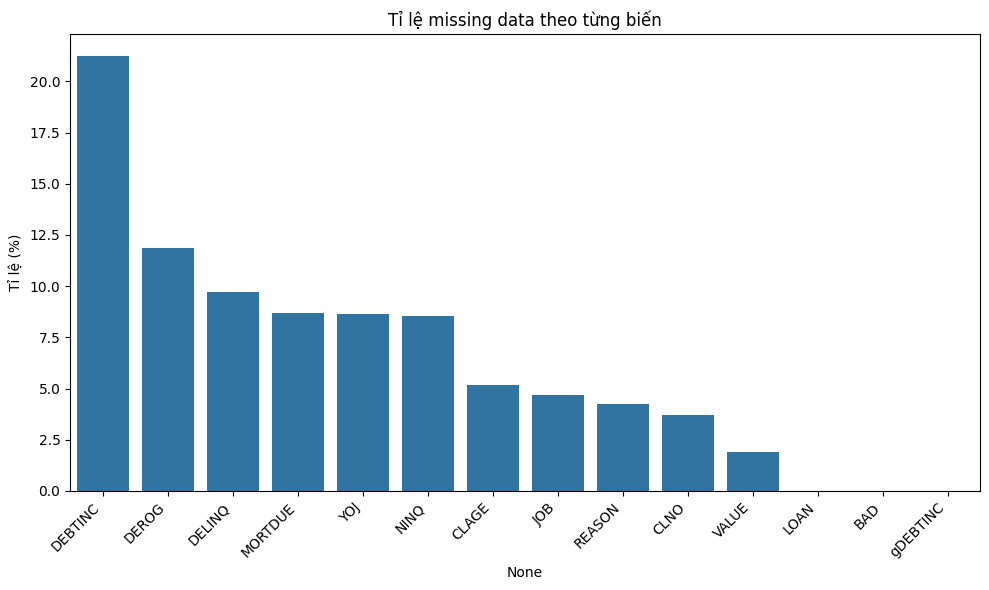

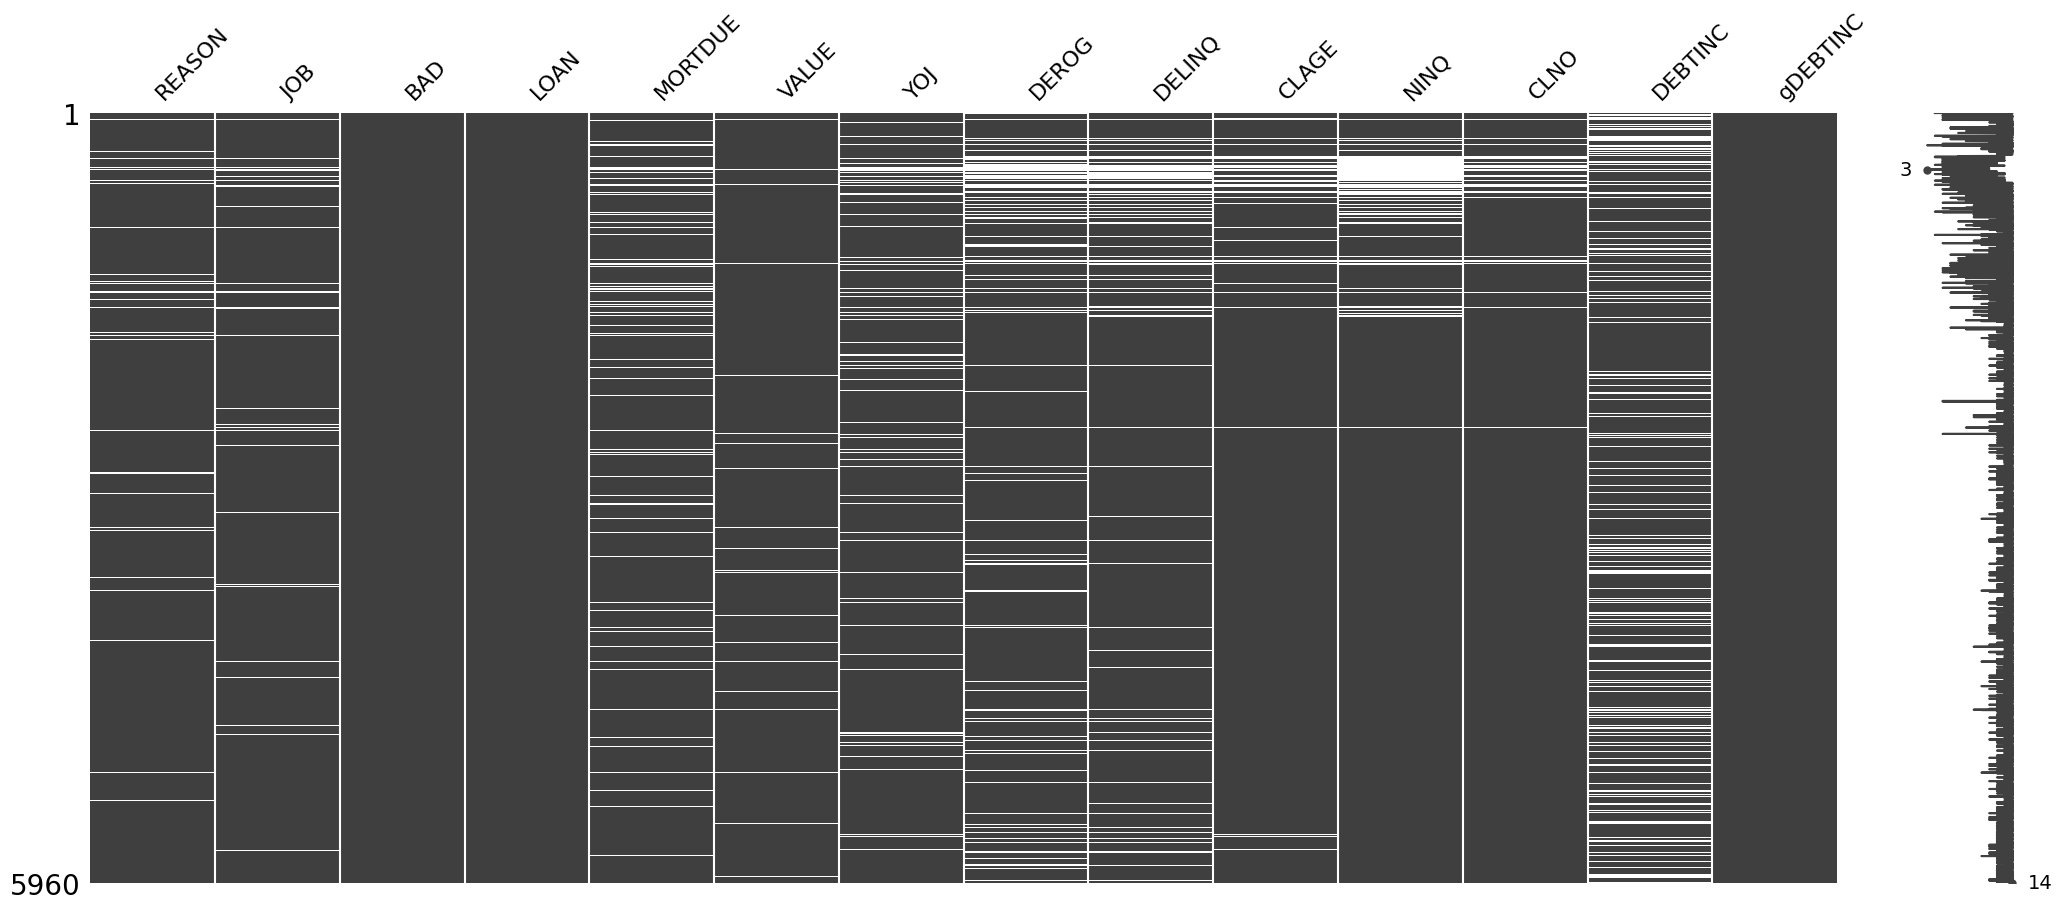

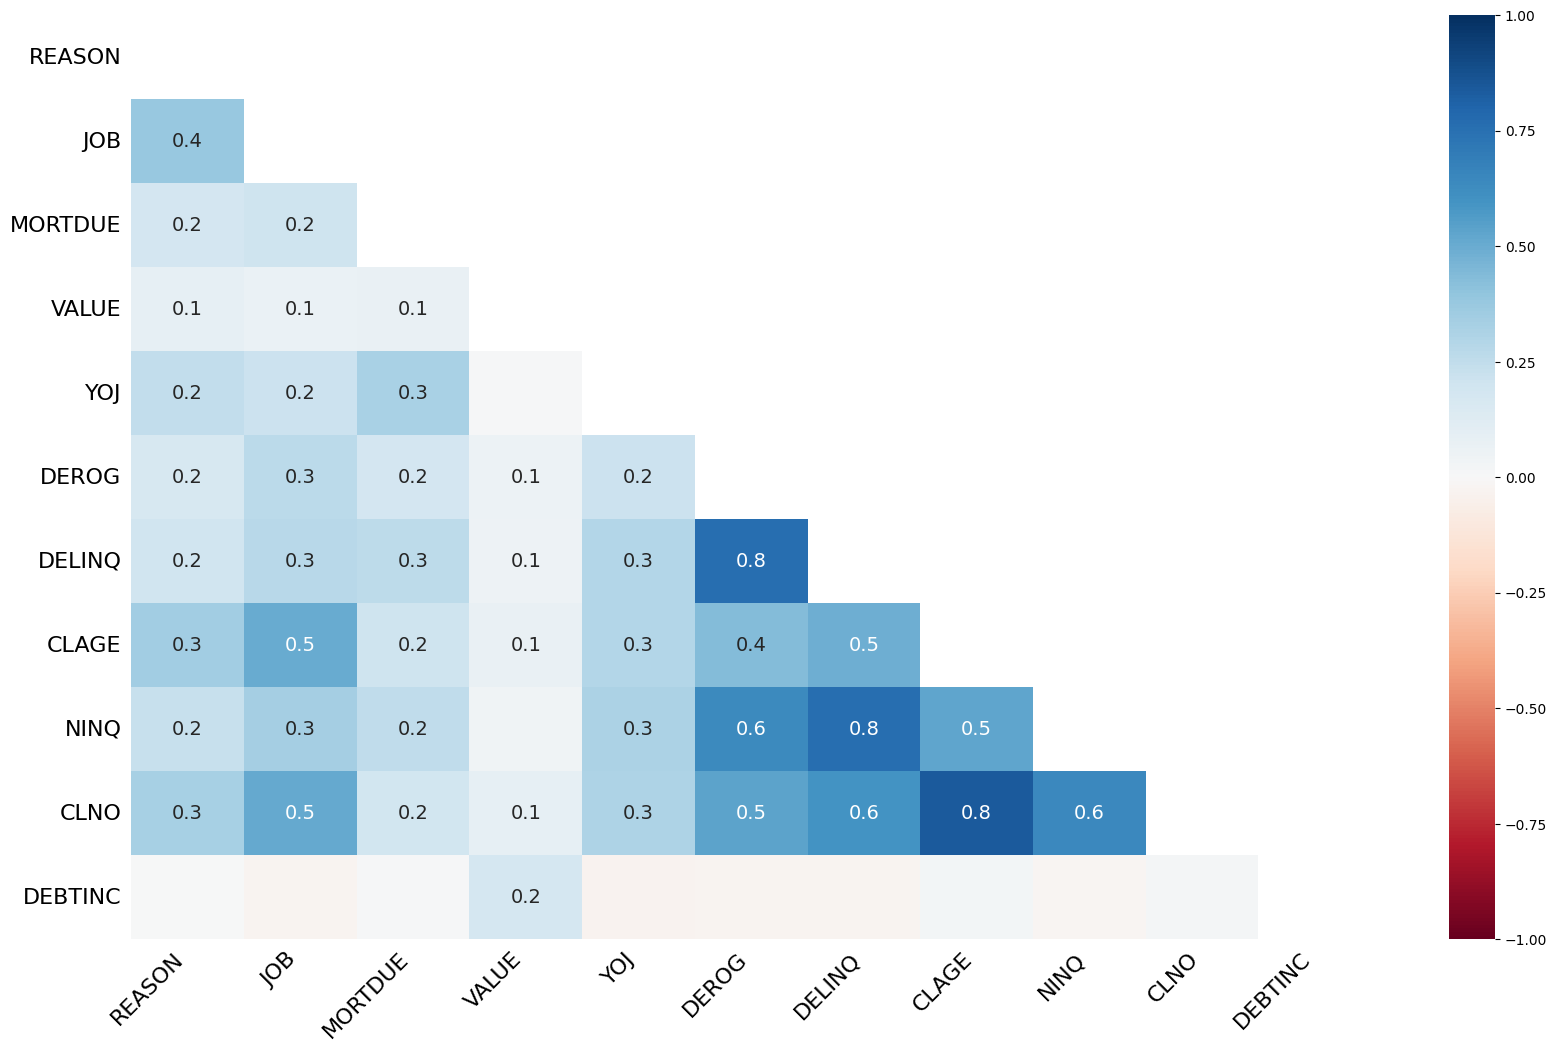

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# === 1. Load data từ file Excel ===
file_path = r"C:\Default-Predict\hmeq.xlsx"
data = pd.read_excel("C:\Default-Predict\hmeq.xlsx", sheet_name=0, engine="openpyxl") # Giả định sheet đầu tiên là dữ liệu

# === 2. Thông tin tổng quan về dữ liệu ===
print("Số dòng:", data.shape[0])
print("Số cột:", data.shape[1])
print("\nTên các biến:", data.columns.tolist())

# === 3. Thống kê missing data theo từng biến ===
missing_per_column = data.isnull().sum()
missing_percent = (missing_per_column / len(data)) * 100

missing_df = pd.DataFrame({
    'MissingCount': missing_per_column,
    'MissingPercent': missing_percent
}).sort_values(by='MissingCount', ascending=False)

print("\nMissing values theo từng biến:")
print(missing_df)

# === 4. Tổng số dòng có ít nhất 1 giá trị thiếu ===
rows_with_missing = data.isnull().any(axis=1).sum()
print(f"\nTổng số dòng có ít nhất một giá trị thiếu: {rows_with_missing} ({rows_with_missing / len(data) * 100:.2f}%)")

# === 5. Trực quan hóa missing data ===

# Biểu đồ dạng bar
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df.index, y=missing_df['MissingPercent'])
plt.xticks(rotation=45, ha='right')
plt.title('Tỉ lệ missing data theo từng biến')
plt.ylabel('Tỉ lệ (%)')
plt.tight_layout()
plt.show()

# Biểu đồ matrix trực quan hóa missing pattern
msno.matrix(data)
plt.show()

# Heatmap correlation giữa missingness
msno.heatmap(data)
plt.show()


   Variable  MissingRate  BAD_if_missing (%)  BAD_if_not_missing (%)  \
10  DEBTINC     0.212584           62.036306                8.587258   
3     VALUE     0.018792           93.750000               18.536252   
5     DEROG     0.118792           12.288136               20.982483   
1       JOB     0.046812            8.243728               20.524556   
6    DELINQ     0.097315           12.413793               20.762082   
4       YOJ     0.086409           12.621359               20.642792   
8      NINQ     0.085570           14.705882               20.440367   
7     CLAGE     0.051678           25.324675               19.656759   
9      CLNO     0.037248           23.873874               19.797839   
0    REASON     0.042282           19.047619               19.989488   
2   MORTDUE     0.086913           20.463320               19.900772   

         p-value  
10  0.000000e+00  
3   1.242722e-85  
5   7.276489e-08  
1   8.023363e-07  
6   2.297274e-06  
4   1.737091e-05  
8 

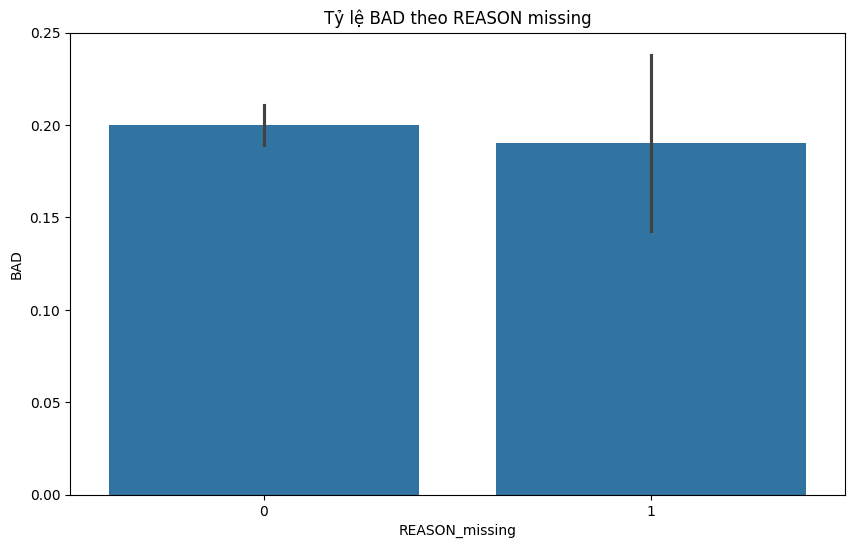

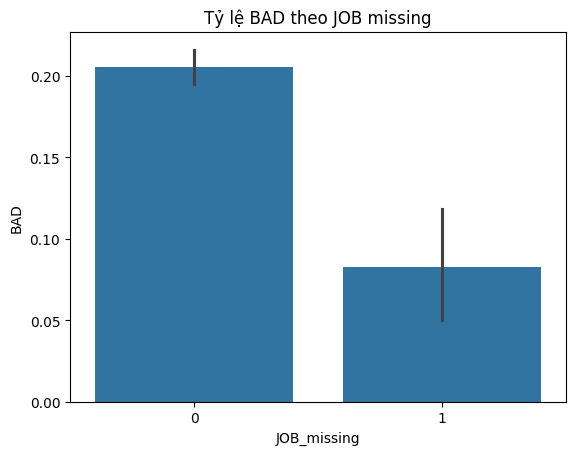

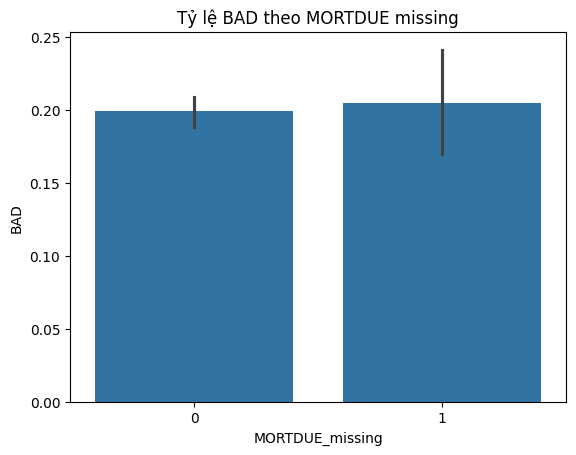

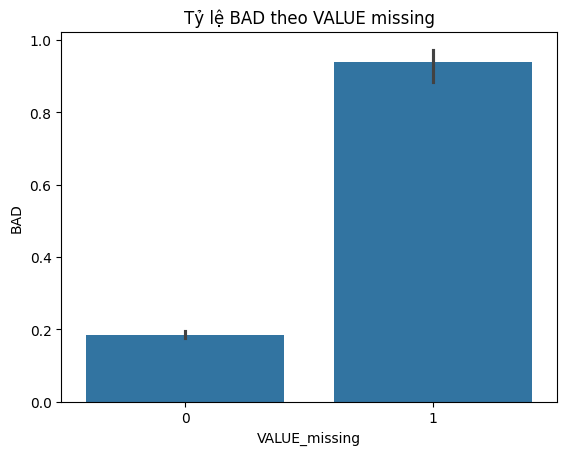

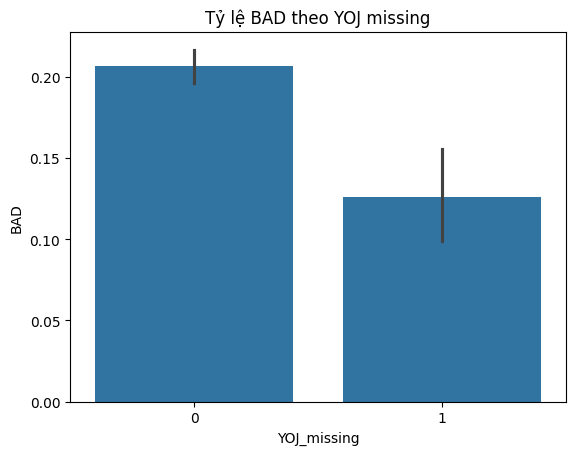

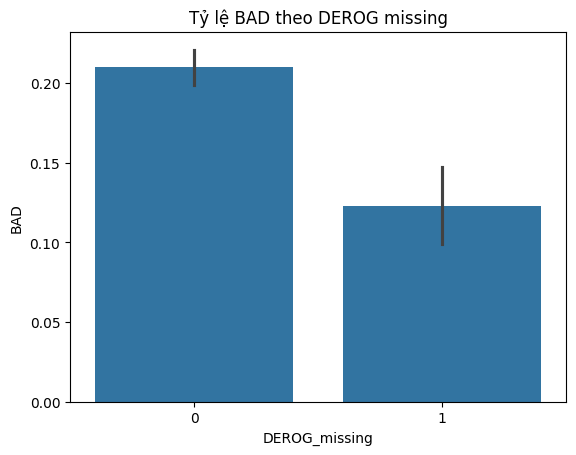

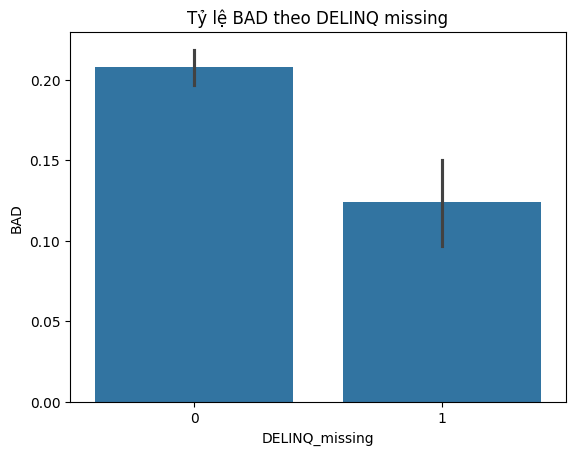

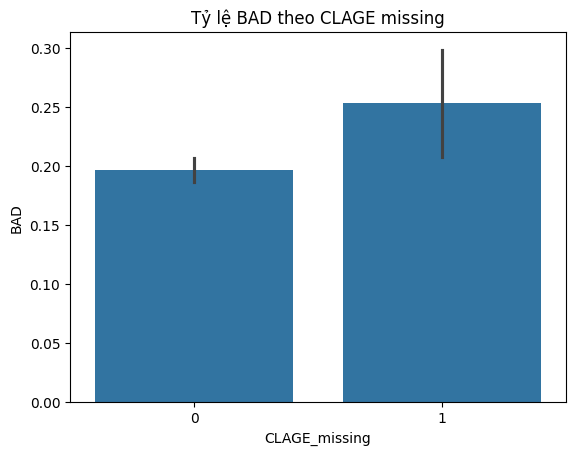

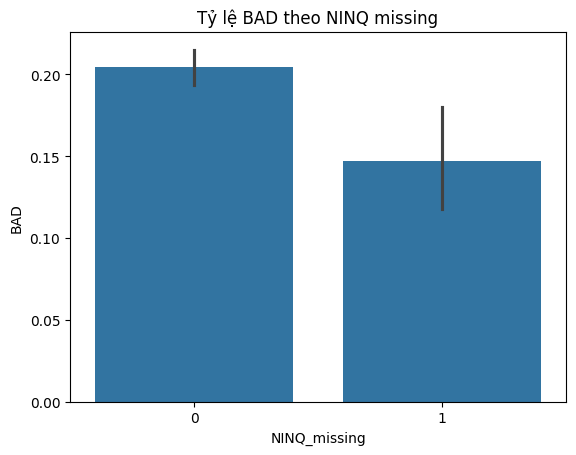

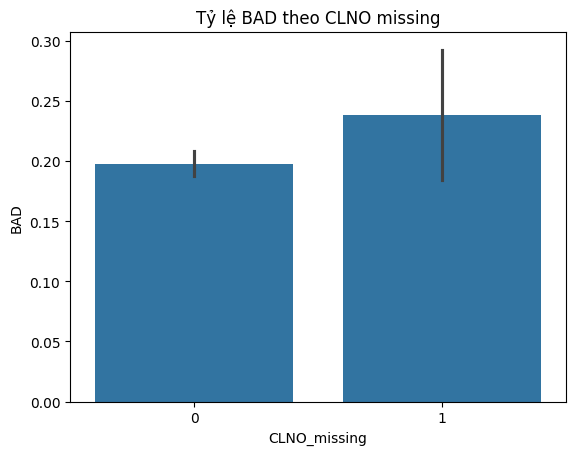

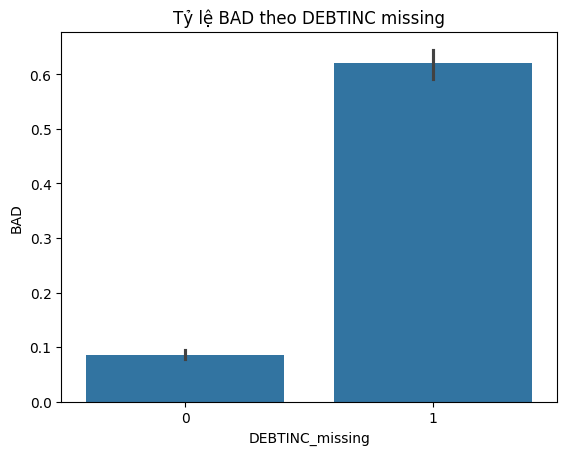

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Giả sử bạn đã có biến `data`
# Tạo danh sách các biến có missing
missing_cols = data.columns[data.isnull().any()].tolist()

# Khởi tạo bảng kết quả
results = []

for col in missing_cols:
    flag_col = col + "_missing"
    data[flag_col] = data[col].isnull().astype(int)

    # Tính tỷ lệ BAD theo flag
    cross_tab = pd.crosstab(data[flag_col], data['BAD'], normalize='index') * 100

    # Chi-squared test
    contingency = pd.crosstab(data[flag_col], data['BAD'])
    chi2, p, _, _ = chi2_contingency(contingency)

    results.append({
        'Variable': col,
        'MissingRate': data[flag_col].mean(),
        'BAD_if_missing (%)': cross_tab.loc[1, 1] if 1 in cross_tab.index else 0,
        'BAD_if_not_missing (%)': cross_tab.loc[0, 1] if 0 in cross_tab.index else 0,
        'p-value': p
    })

# Đưa ra kết quả
missing_analysis = pd.DataFrame(results).sort_values('p-value')
print(missing_analysis)

# Vẽ biểu đồ trực quan nếu muốn
plt.figure(figsize=(10, 6))
for var in missing_cols:
    sns.barplot(x=var + "_missing", y="BAD", data=data, estimator=lambda x: sum(x)/len(x))
    plt.title(f"Tỷ lệ BAD theo {var} missing")
    plt.show()


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop biến không cần thiết
data = data.drop(columns=['gDEBTINC'])


Numeric variables: ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
Categorical variables: ['REASON', 'JOB', 'BAD']


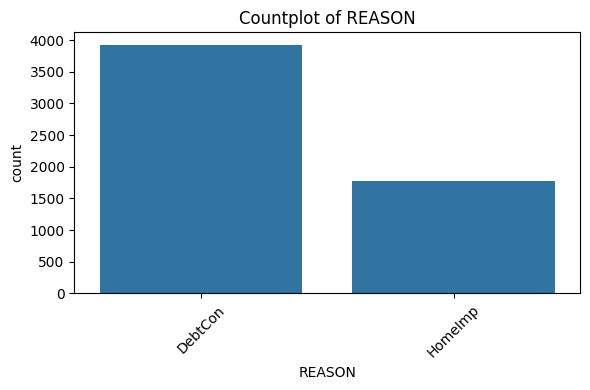

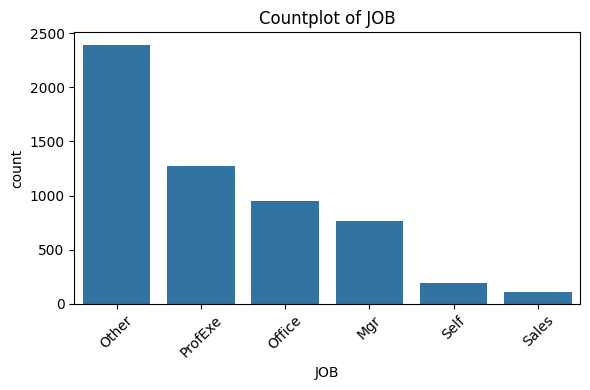

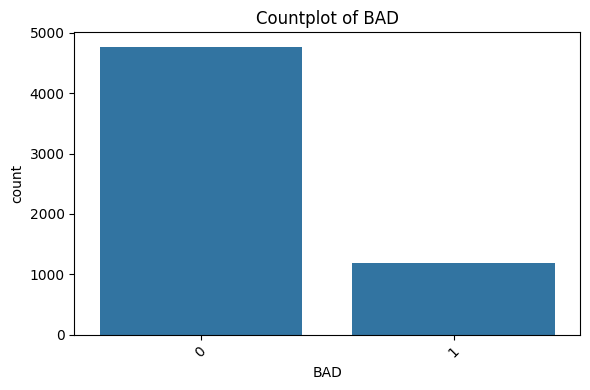

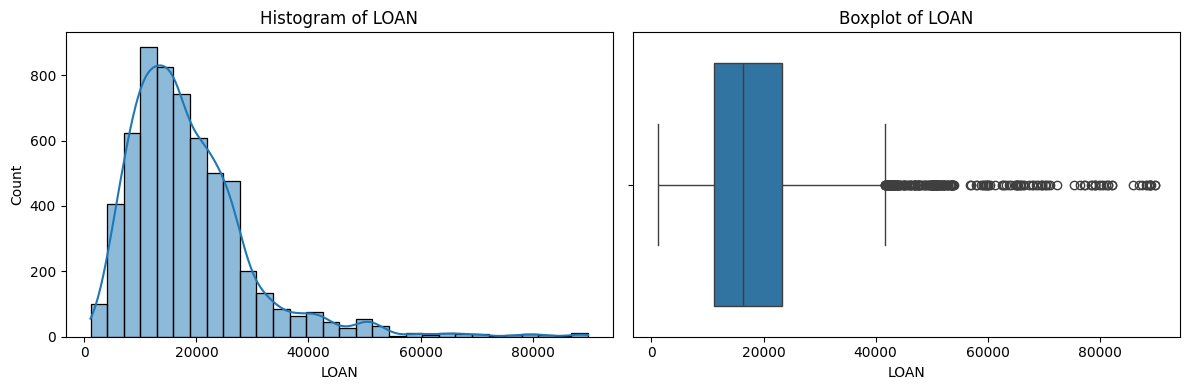

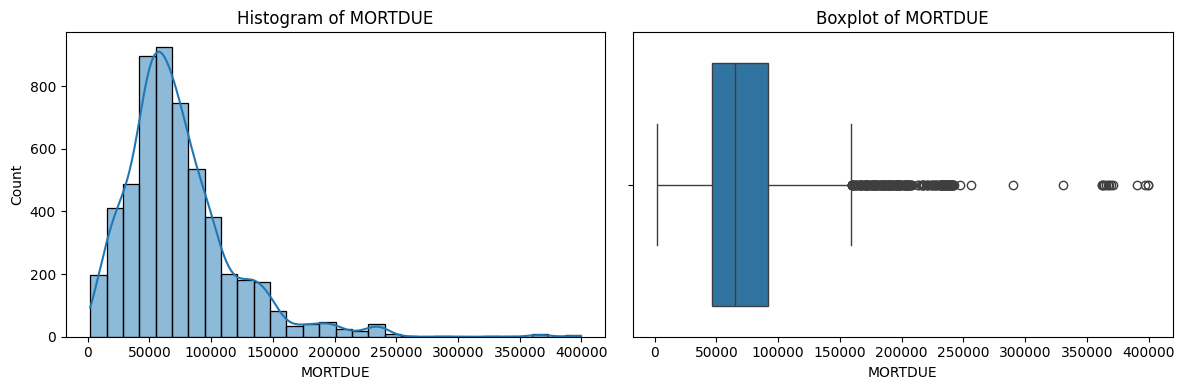

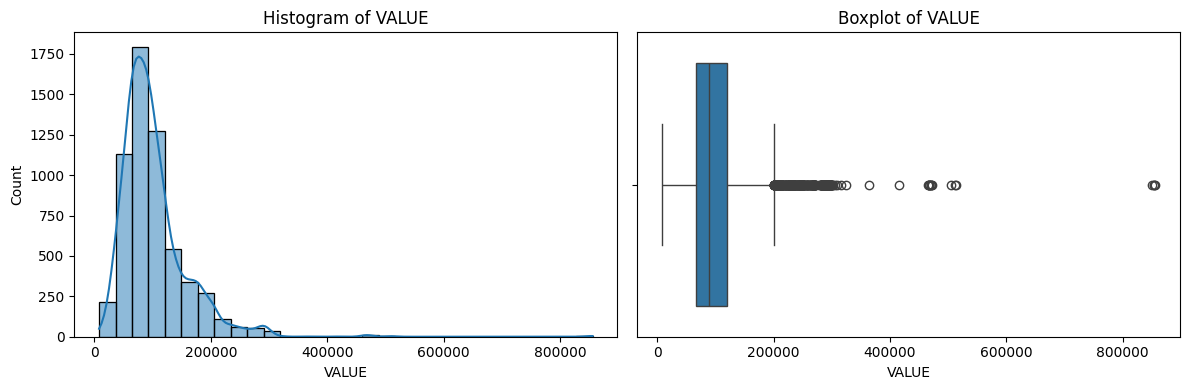

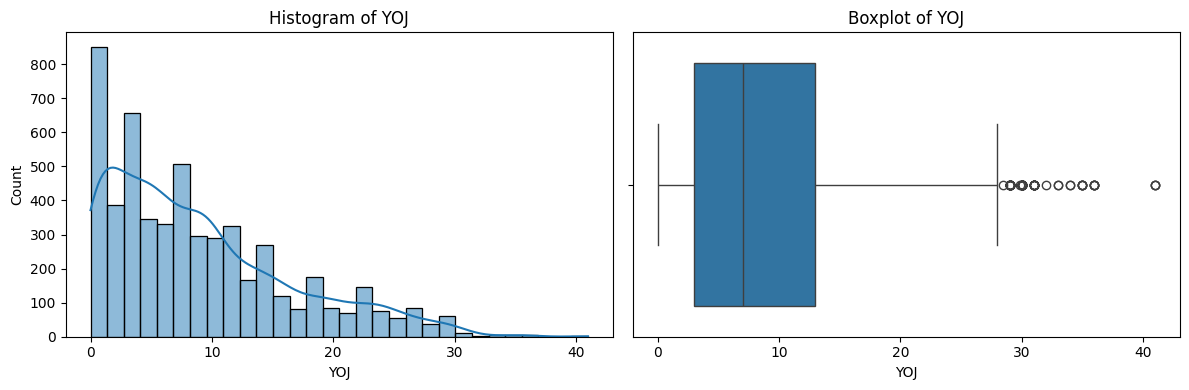

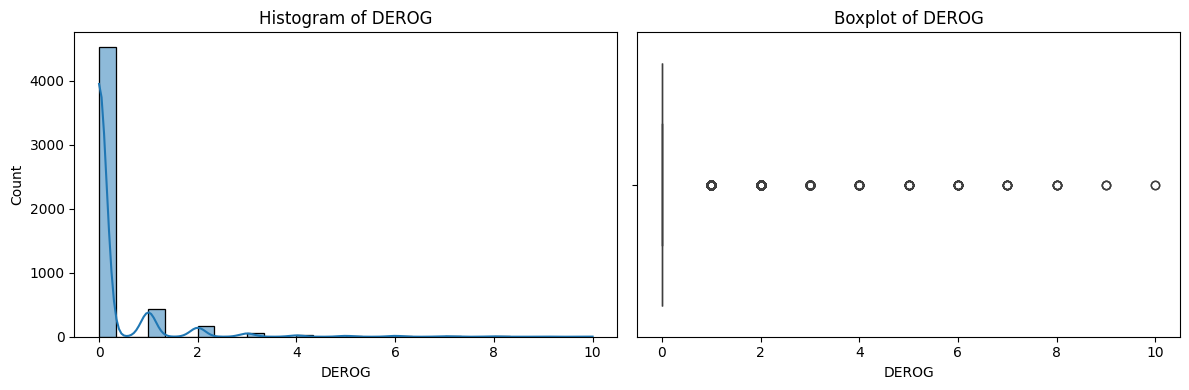

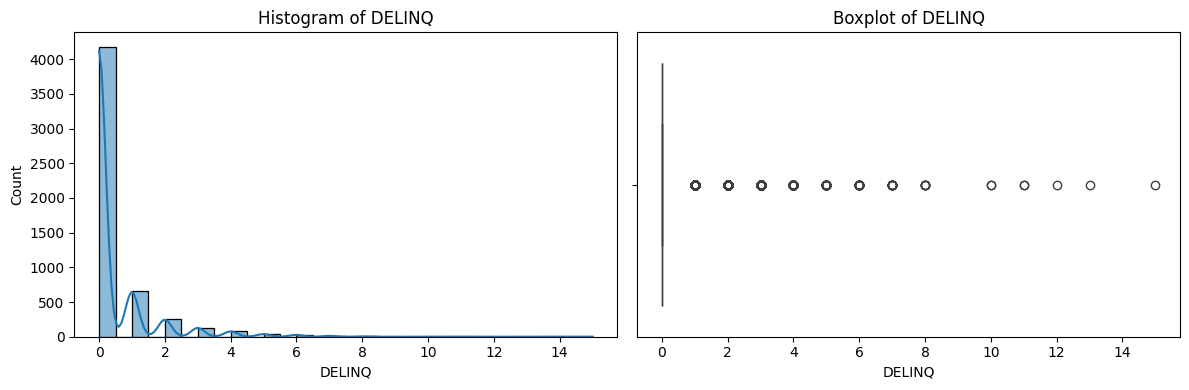

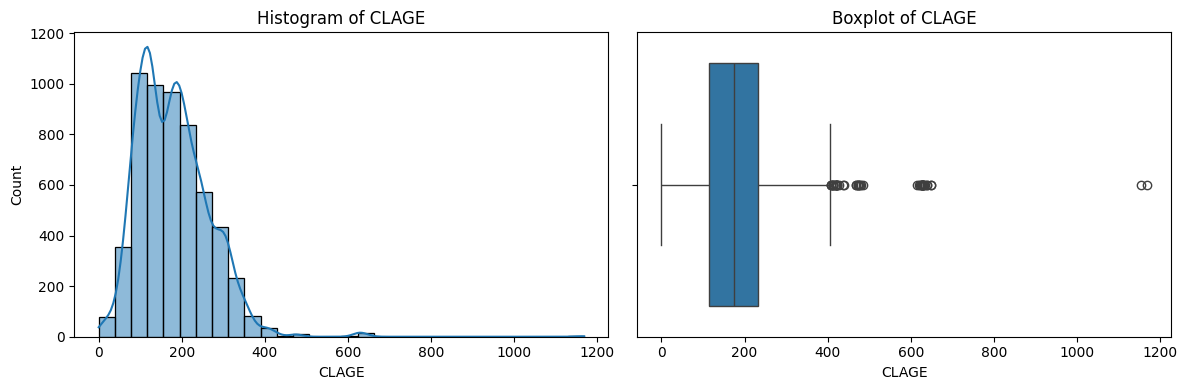

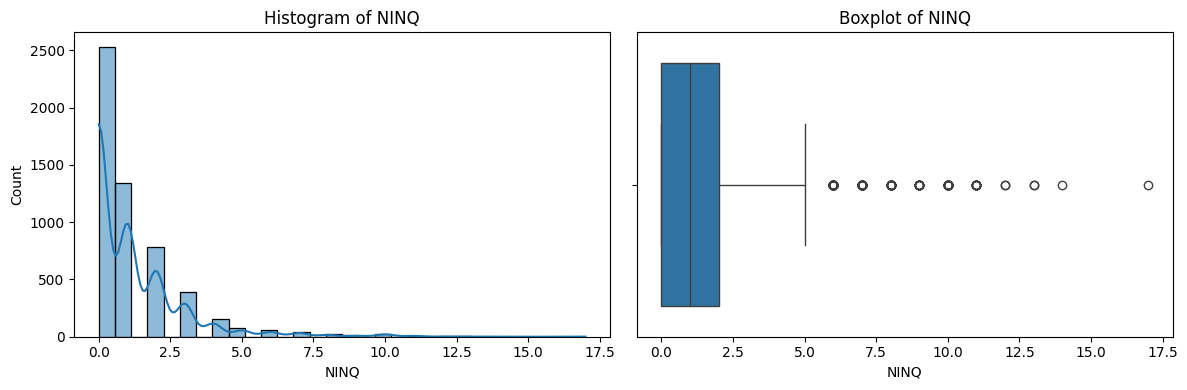

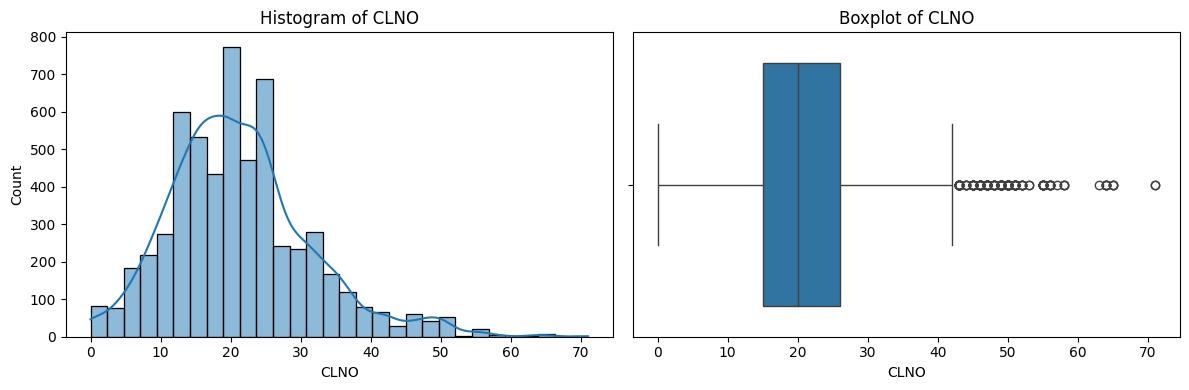

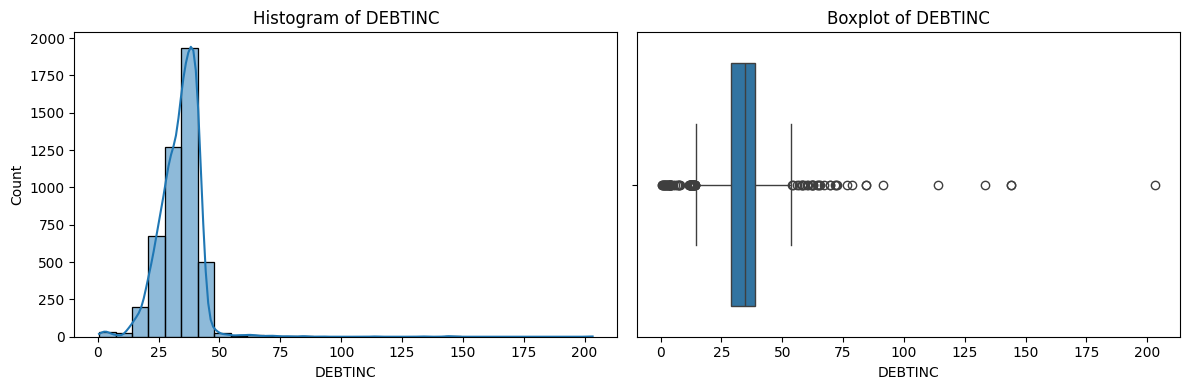

In [4]:

# Phân loại biến
binary_vars = ['BAD']
categorical_vars = data.select_dtypes(include=['object']).columns.tolist() + binary_vars
numeric_vars = [col for col in data.select_dtypes(include=['int64', 'float64']).columns if col not in binary_vars]

print("Numeric variables:", numeric_vars)
print("Categorical variables:", categorical_vars)

# Vẽ biểu đồ biến phân loại
for col in categorical_vars:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Vẽ histogram và boxplot cho biến số
for col in numeric_vars:
    plt.figure(figsize=(12,4))
    
    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(data[col].dropna(), bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()


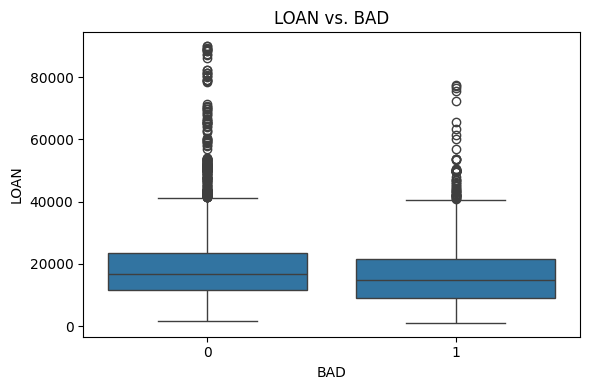

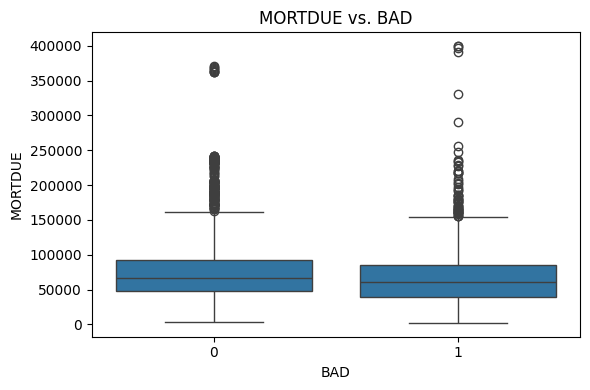

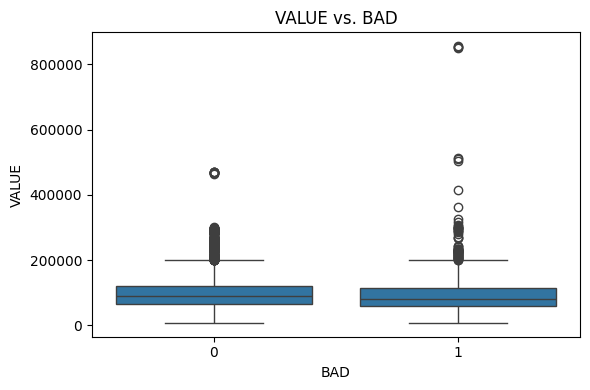

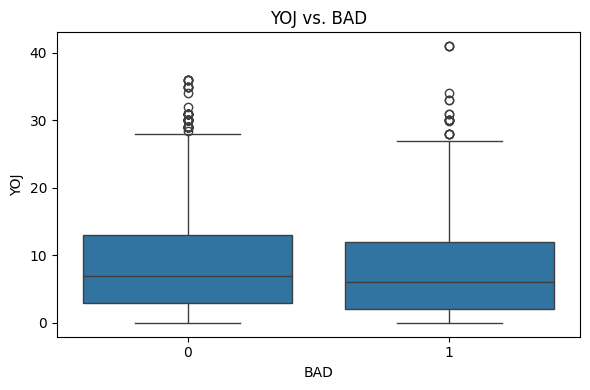

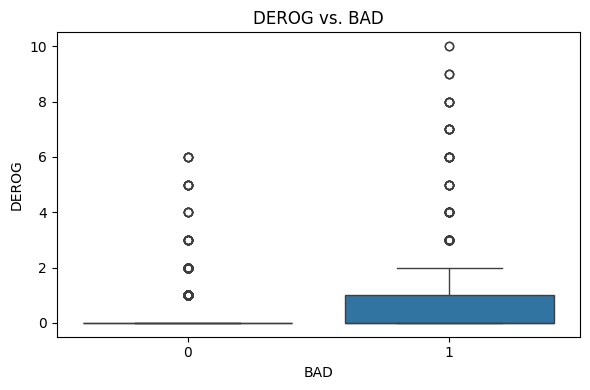

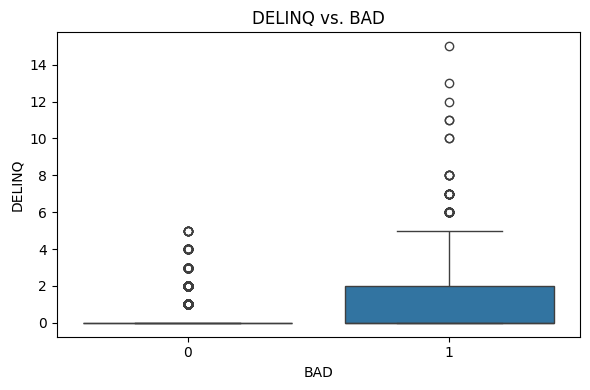

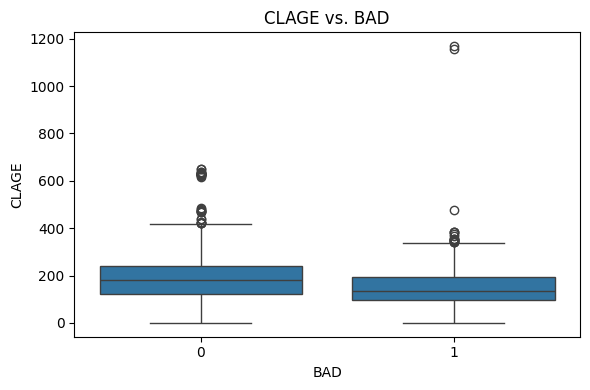

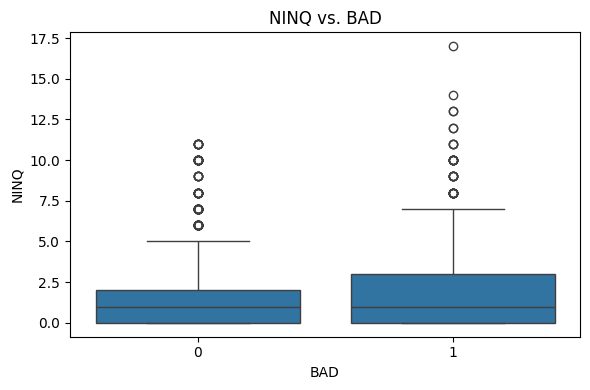

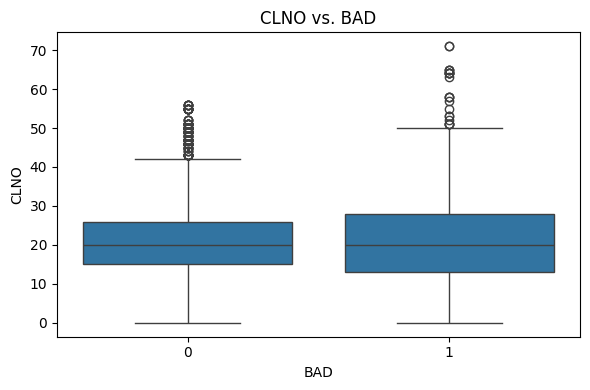

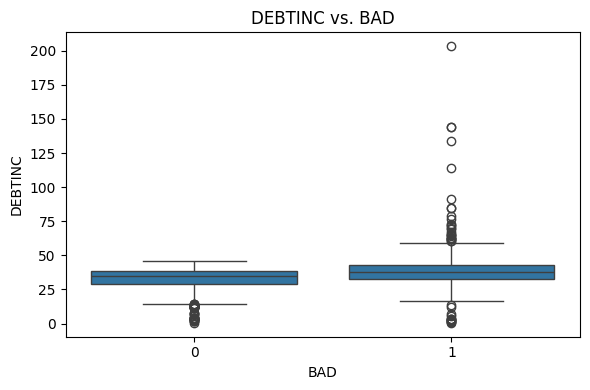

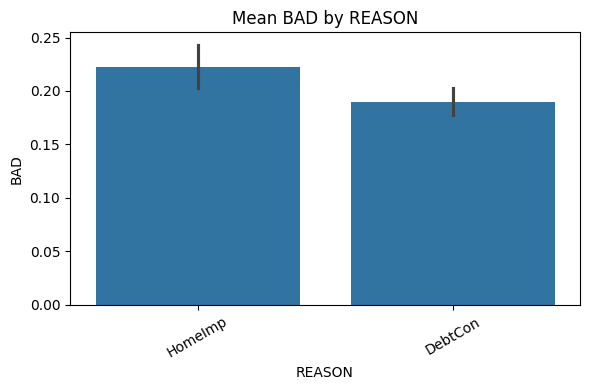

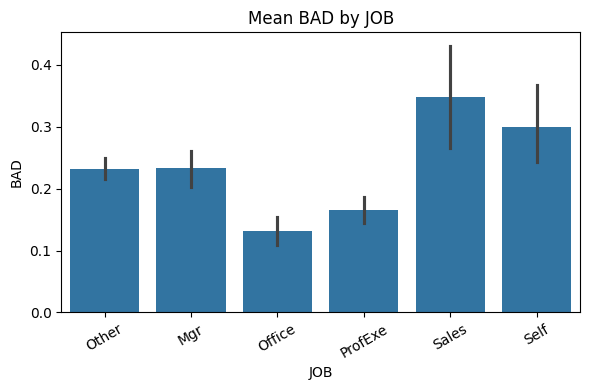

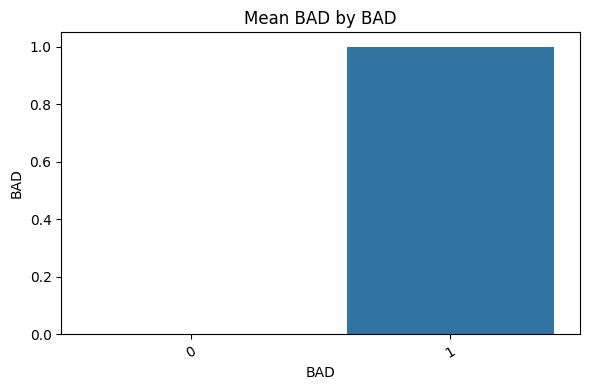

In [5]:
target_var = 'BAD'
# === 1. Bivariate plots: Numeric vs. Target (Boxplot) ===
for var in numeric_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=target_var, y=var)
    plt.title(f"{var} vs. {target_var}")
    plt.tight_layout()
    plt.show()

# === 2. Bivariate plots: Categorical vs. Target (Barplot) ===
for var in categorical_vars:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=data, x=var, y=target_var, estimator=lambda x: sum(x)/len(x))
    plt.title(f"Mean {target_var} by {var}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

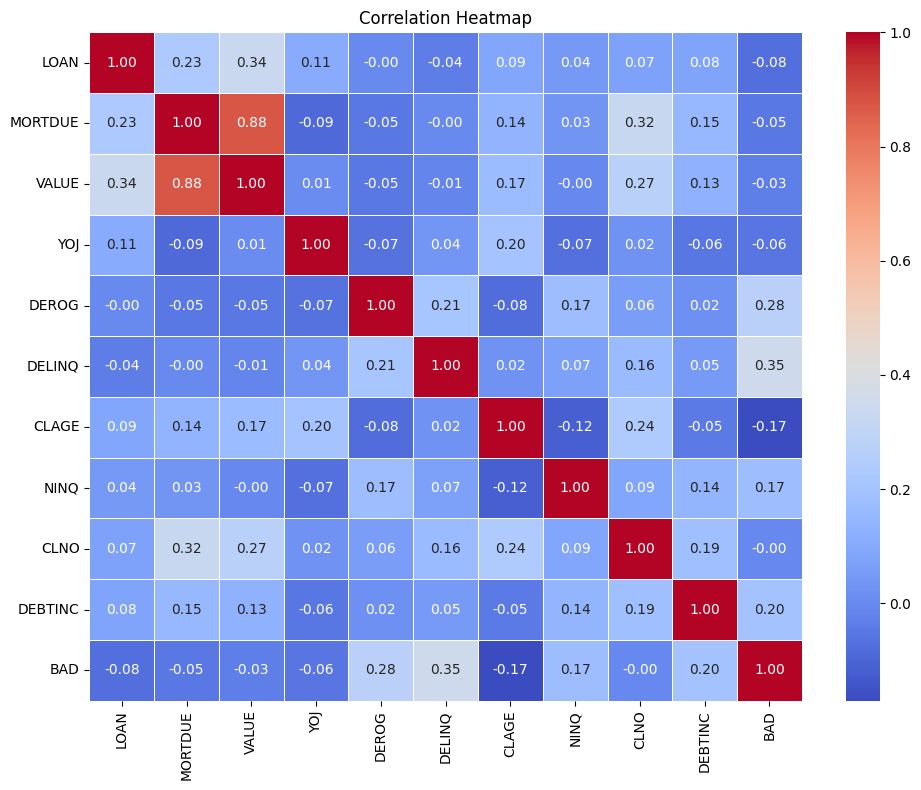

In [6]:
# Tính ma trận tương quan
corr_matrix = data[numeric_vars + [target_var]].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
